In [21]:
import mlflow
import numpy as np
import pandas as pd
from pathlib import Path
import sys

# Add model/src to path for imports
sys.path.insert(0, str(Path("../model/src").resolve()))

from config import FEATURE_SETS
from features import build_target, build_train_test_data
from data_load import load_data

# Load data and recreate test split
df = load_data()

🔌 Connecting to Neon...
🔒 Connection closed.


### Error analysis of price per sqm model

In [22]:
# build target col for price_p_Sqm
df, target_col = build_target(df, "price_m2_eur")

# This creates the SAME test split as training (random_state=42)
X_train, X_test, y_train, y_test = build_train_test_data(df, target_col, FEATURE_SETS["all"], test_size=0.2)
print("Train-test split performed!")
print(f"Length of test set: {len(y_test)}")

# Load your trained model for price p/sqm
mlruns = Path("../model/mlruns").resolve().as_uri()
mlflow.set_tracking_uri(mlruns)
model_price_p_sqm = mlflow.sklearn.load_model("models:/RealEstatePricePerSqm/latest")

# Make predictions on test set
y_pred_sqm_log = model_price_p_sqm.predict(X_test)

# Convert from log space back to EUR
y_actual_sqm_eur = np.exp(y_test)
y_pred_sqm_eur = np.exp(y_pred_sqm_log)

# Create error dataframe
errors_df_price_p_sqm = pd.DataFrame({
    'actual_price_p_sqm': y_actual_sqm_eur,
    'predicted_price_p_sqm': y_pred_sqm_eur,
    'absolute_error': np.abs(y_actual_sqm_eur - y_pred_sqm_eur),
    'percent_error': (np.abs(y_actual_sqm_eur - y_pred_sqm_eur) / y_actual_sqm_eur) * 100
})

# Now you can analyze errors!
print(errors_df_price_p_sqm.describe())

Train-test split performed!
Length of test set: 963
       actual_price_p_sqm  predicted_price_p_sqm  absolute_error  \
count          963.000000             963.000000      963.000000   
mean          2576.901350            2556.781552      317.737918   
std            656.790582             471.420709      316.600590   
min             23.000000            1327.756468        0.524181   
25%           2190.000000            2252.051147      102.808049   
50%           2500.000000            2479.886788      228.080315   
75%           2897.500000            2776.988860      431.479103   
max           5818.000000            4405.492223     2333.792465   

       percent_error  
count     963.000000  
mean       18.392725  
std       182.861542  
min         0.026662  
25%         4.206107  
50%         9.401283  
75%        17.143106  
max      5672.854207  


In [10]:
errors_df_price_p_sqm

,actual_price_p_sqm,predicted_price_p_sqm,absolute_error,percent_error
2014,1814.0,1972.074406,158.074406,8.714135
1859,2541.0,2692.919122,151.919122,5.978714
4386,3019.0,2661.953312,357.046688,11.826654
709,2498.0,2694.885548,196.885548,7.881727
8,1985.0,2351.499925,366.499925,18.463472
...,...,...,...,...
3160,2293.0,2190.866725,102.133275,4.454133
554,2562.0,2320.776914,241.223086,9.415421
1007,2039.0,2237.746818,198.746818,9.747269
1035,2564.0,2689.456152,125.456152,4.892986


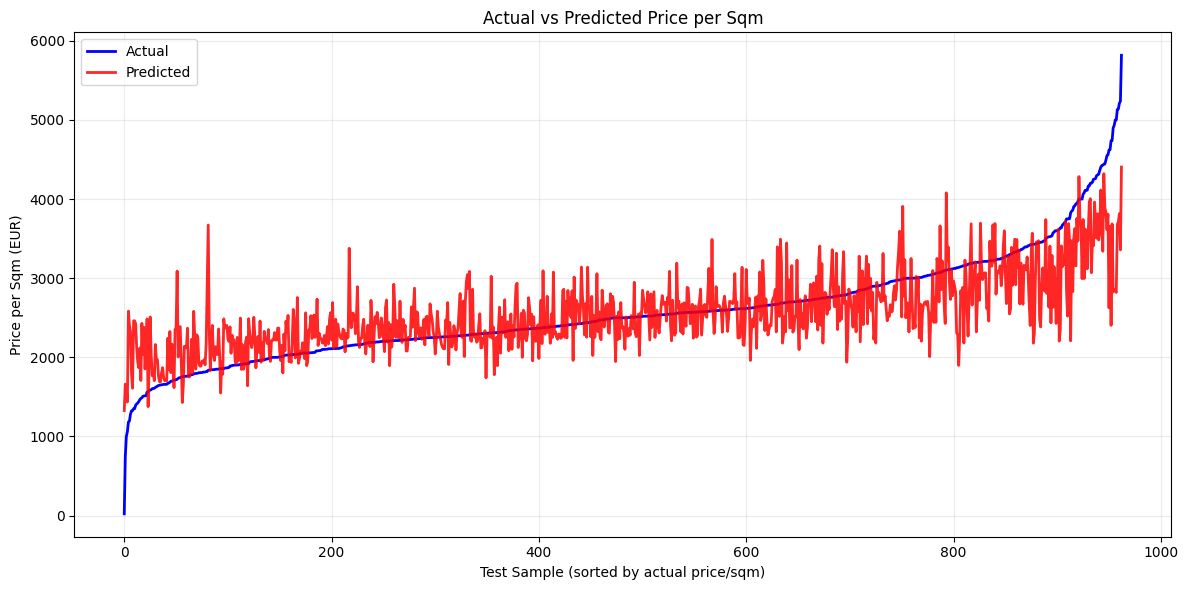

In [13]:
import matplotlib.pyplot as plt

# Sort by actual values for a cleaner side-by-side curve comparison
plot_df = errors_df_price_p_sqm.sort_values("actual_price_p_sqm").reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(plot_df.index, plot_df["actual_price_p_sqm"], color="blue", label="Actual", linewidth=2)
plt.plot(plot_df.index, plot_df["predicted_price_p_sqm"], color="red", label="Predicted", linewidth=2, alpha=0.85)
plt.title("Actual vs Predicted Price per Sqm")
plt.xlabel("Test Sample (sorted by actual price/sqm)")
plt.ylabel("Price per Sqm (EUR)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

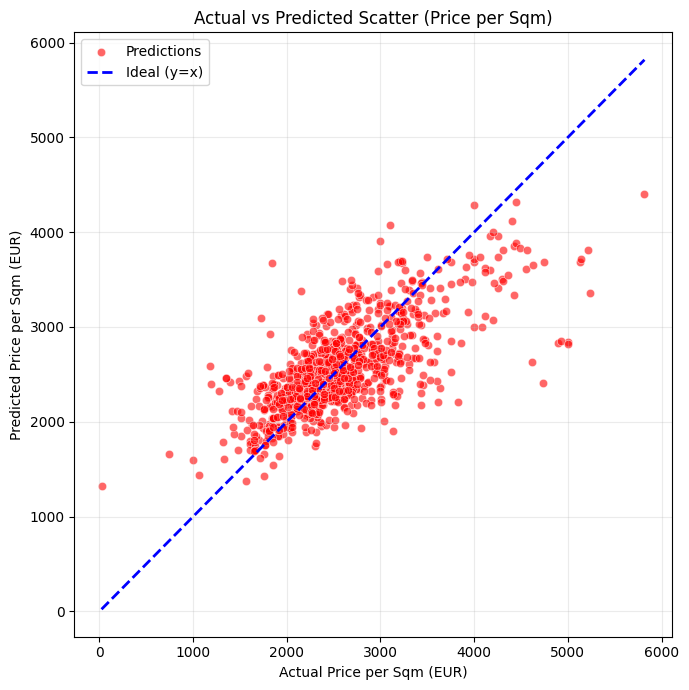

In [17]:
# Scatter plot: actual vs predicted with ideal y=x reference
plt.figure(figsize=(7, 7))
plt.scatter(
    errors_df_price_p_sqm["actual_price_p_sqm"],
    errors_df_price_p_sqm["predicted_price_p_sqm"],
    color="red",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5,
    label="Predictions"
 )

# Ideal predictions line (y = x)
min_val = min(
    errors_df_price_p_sqm["actual_price_p_sqm"].min(),
    errors_df_price_p_sqm["predicted_price_p_sqm"].min()
 )
max_val = max(
    errors_df_price_p_sqm["actual_price_p_sqm"].max(),
    errors_df_price_p_sqm["predicted_price_p_sqm"].max()
 )
plt.plot([min_val, max_val], [min_val, max_val], "b--", linewidth=2, label="Ideal (y=x)")

plt.title("Actual vs Predicted Scatter (Price per Sqm)")
plt.xlabel("Actual Price per Sqm (EUR)")
plt.ylabel("Predicted Price per Sqm (EUR)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

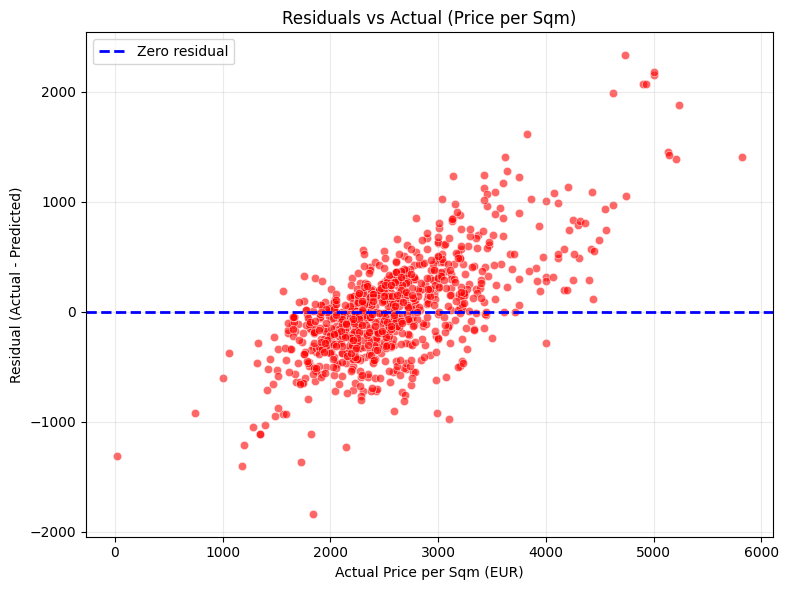

In [19]:
# Residuals = actual - predicted
errors_df_price_p_sqm["residuals"] = (
    errors_df_price_p_sqm["actual_price_p_sqm"]
    - errors_df_price_p_sqm["predicted_price_p_sqm"]
)

# Residual plot: x=actual price per sqm, y=residual
plt.figure(figsize=(8, 6))
plt.scatter(
    errors_df_price_p_sqm["actual_price_p_sqm"],
    errors_df_price_p_sqm["residuals"],
    color="red",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5
 )

# Zero-error reference line
plt.axhline(0, color="blue", linestyle="--", linewidth=2, label="Zero residual")

plt.title("Residuals vs Actual (Price per Sqm)")
plt.xlabel("Actual Price per Sqm (EUR)")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics in log space
r2_log = r2_score(y_test, y_pred_sqm_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_sqm_log))
mae_log = mean_absolute_error(y_test, y_pred_sqm_log)

# Metrics in original EUR/sqm space
r2_eur = r2_score(y_actual_sqm_eur, y_pred_sqm_eur)
rmse_eur = np.sqrt(mean_squared_error(y_actual_sqm_eur, y_pred_sqm_eur))
mae_eur = mean_absolute_error(y_actual_sqm_eur, y_pred_sqm_eur)

metrics_df_sqm = pd.DataFrame(
    [
        {"scale": "log(price_per_sqm)", "R2": r2_log, "RMSE": rmse_log, "MAE": mae_log},
        {"scale": "price_per_sqm_eur", "R2": r2_eur, "RMSE": rmse_eur, "MAE": mae_eur},
    ]
)

metrics_df_sqm

,scale,R2,RMSE,MAE
0,log(price_per_sqm),0.448538,0.212480,0.126489
1,price_per_sqm_eur,0.533355,448.429739,317.737918


In [ ]:
# Log-space comparison for sqm model
log_compare_df_sqm = pd.DataFrame({
    "actual_log_price_p_sqm": y_test,
    "predicted_log_price_p_sqm": y_pred_sqm_log
}).reset_index(drop=True)

# Residuals in log space
log_compare_df_sqm["residual_log"] = (
    log_compare_df_sqm["actual_log_price_p_sqm"]
    - log_compare_df_sqm["predicted_log_price_p_sqm"]
)

# 1) Line comparison (sorted by actual log value)
plot_log_df = log_compare_df_sqm.sort_values("actual_log_price_p_sqm").reset_index(drop=True)
plt.figure(figsize=(12, 6))
plt.plot(plot_log_df.index, plot_log_df["actual_log_price_p_sqm"], color="blue", label="Actual log", linewidth=2)
plt.plot(plot_log_df.index, plot_log_df["predicted_log_price_p_sqm"], color="red", label="Predicted log", linewidth=2, alpha=0.85)
plt.title("Actual vs Predicted in Log Scale (Price per Sqm)")
plt.xlabel("Test Sample (sorted by actual log price/sqm)")
plt.ylabel("Log Price per Sqm")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 2) Residual plot in log space
plt.figure(figsize=(8, 6))
plt.scatter(
    log_compare_df_sqm["actual_log_price_p_sqm"],
    log_compare_df_sqm["residual_log"],
    color="red",
    alpha=0.6,
    edgecolor="white",
    linewidth=0.5
 )
plt.axhline(0, color="blue", linestyle="--", linewidth=2, label="Zero residual")
plt.title("Log Residuals vs Actual Log Price (Price per Sqm)")
plt.xlabel("Actual Log Price per Sqm")
plt.ylabel("Residual Log (Actual - Predicted)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Quick numeric summary
log_compare_df_sqm[["actual_log_price_p_sqm", "predicted_log_price_p_sqm", "residual_log"]].describe()

### Error analysis of total price eur

In [9]:
# build target col for price
df, target_col = build_target(df, "total_price_eur")

# This creates the SAME test split as training (random_state=42)
X_train, X_test, y_train, y_test = build_train_test_data(df, target_col, FEATURE_SETS["all"], test_size=0.2)
print("Train-test split performed!")
print(f"Length of test set: {len(y_test)}")

# Load your trained model for price p/sqm
mlruns = Path("../model/mlruns").resolve().as_uri()
mlflow.set_tracking_uri(mlruns)
model_total_price = mlflow.sklearn.load_model("models:/RealEstateTotalPrice/latest")

# Make predictions on test set
y_pred_log = model_total_price.predict(X_test)

# Convert from log space back to EUR
y_actual_eur = np.exp(y_test)
y_pred_eur = np.exp(y_pred_log)

# Create error dataframe
errors_df_total_price = pd.DataFrame({
    'actual_price_p_sqm': y_actual_eur,
    'predicted_price_p_sqm': y_pred_eur,
    'absolute_error': np.abs(y_actual_eur - y_pred_eur),
    'percent_error': (np.abs(y_actual_eur - y_pred_eur) / y_actual_eur) * 100
})

# Now you can analyze errors!
print(errors_df_total_price.describe())

Train-test split performed!
Length of test set: 963
       actual_price_p_sqm  predicted_price_p_sqm  absolute_error  \
count          963.000000             963.000000      963.000000   
mean        234246.545171          231963.862006    29500.618435   
std          78872.225182           63750.997954    29711.493202   
min          67002.000000           97353.574283        4.669276   
25%         175036.000000          183016.957898     9862.383432   
50%         227035.000000          226171.491371    20706.856028   
75%         296590.000000          281921.347429    39027.411758   
max         615060.000000          405542.346896   242847.025113   

       percent_error  
count     963.000000  
mean       13.350271  
std        14.435563  
min         0.001822  
25%         4.435808  
50%         9.392611  
75%        17.826475  
max       132.650628  
